# Traffic-Sign-Localization-Detection-YOLO-Annotated
[Dataset](https://www.kaggle.com/datasets/ahemateja19bec1025/trafficsignlocalizationdetectionyoloannotated)

In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("ahemateja19bec1025/trafficsignlocalizationdetectionyoloannotated")

print("Path to dataset files:", path)
print(os.listdir(path))

to_train_path = path

100%|██████████| 44.5M/44.5M [00:00<00:00, 137MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ahemateja19bec1025/trafficsignlocalizationdetectionyoloannotated/versions/9
['Custom_data.yaml', 'labels_YOLO_Traffic_Sign.csv', 'TrafficSignLocalizationandDetection']


# Task
Generate YOLO training using the folder structure "/kaggle/input/traffic-signs-dataset-in-yolo-format/train/images", "/kaggle/input/traffic-signs-dataset-in-yolo-format/train/labels", "/kaggle/input/traffic-signs-dataset-in-yolo-format/test/images", and "/kaggle/input/traffic-signs-dataset-in-yolo-format/test/labels" with `ultralytics`.

## Install ultralytics

### Subtask:
Install the `ultralytics` library.


**Reasoning**:
The subtask is to install the `ultralytics` library. This can be done using pip in a code cell.



In [ ]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 845.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

## Create data.yaml

### Subtask:
Create a `data.yaml` file that specifies the paths to your training and validation image and label directories, the number of classes, and the class names.


**Reasoning**:
Create the data_yaml_dict, import the yaml library, and write the data_yaml_dict to a file named data.yaml.



In [ ]:
import yaml

data_yaml_dict = {
    'train': '/kaggle/input/traffic-signs-dataset-in-yolo-format/train/images',
    'val': '/kaggle/input/traffic-signs-dataset-in-yolo-format/test/images',
    'nc': 4,
    'names': ['prohibitory', 'danger', 'mandatory', 'other']
}

with open('data.yaml', 'w') as f:
    yaml.dump(data_yaml_dict, f)

import os

with open('data.yaml', 'r') as f:
    data_yaml_dict = yaml.safe_load(f)

print(data_yaml_dict)
print(os.listdir())
print(os.curdir)

{'names': ['prohibitory', 'danger', 'mandatory', 'other'], 'nc': 4, 'train': '/kaggle/input/traffic-signs-dataset-in-yolo-format/train/images', 'val': '/kaggle/input/traffic-signs-dataset-in-yolo-format/test/images'}
['.config', 'data.yaml', 'sample_data']
.


## Load a yolo model

### Subtask:
Load a pre-trained YOLO model using the `ultralytics` library.


**Reasoning**:
Load a pre-trained YOLO model using the `ultralytics` library by importing the `YOLO` class and instantiating a model.



In [ ]:
from ultralytics import YOLO

model = YOLO("yolo12n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 5.34M/5.34M [00:00<00:00, 95.8MB/s]


In [ ]:
import yaml
import os

data = {
    'names': [
        'Cycle Zone',
        'Danger Ahead',
        'Deer Zone',
        'End of Right Road -Go straight-',
        'Give Way',
        'Go Left or Straight',
        'Go Right or Straight',
        'Go Straight',
        'Huddle Road',
        'Left Curve Ahead',
        'Left Sharp Curve',
        'No Entry',
        'No Over Taking Trucks',
        'No Over Taking',
        'No Stopping',
        'No Waiting',
        'Pedestrian',
        'Right Curve Ahead',
        'Right Sharp Curve',
        'Road Work',
        'RoundAbout',
        'Slippery Road',
        'Snow Warning Sign',
        'Speed Limit 100',
        'Speed Limit 120',
        'Speed Limit 20',
        'Speed Limit 30',
        'Speed Limit 50',
        'Speed Limit 60',
        'Speed Limit 70',
        'Speed Limit 80',
        'Stop',
        'Traffic Signals Ahead',
        'Truck Sign',
        'Turn Left',
        'Turn Right'
    ],
    'nc': 36,
    'train': os.path.join(to_train_path,'TrafficSignLocalizationandDetection/train/images'),
    'val': os.path.join(to_train_path,'TrafficSignLocalizationandDetection/valid/images')
}

# Define the filename for the YAML file
yaml_filename = 'traffic_signs_dataset.yaml'

try:
    with open(yaml_filename, 'w') as file:
        yaml.dump(data, file, default_flow_style=False, sort_keys=False)
    print(f"Successfully created '{yaml_filename}' with the provided data.")

    # Optional: Read and print the content to verify
    print(f"\nContent of '{yaml_filename}':")
    with open(yaml_filename, 'r') as file:
        print(file.read())

except Exception as e:
    print(f"An error occurred: {e}")

# Clean up the created file (optional, for demonstration purposes)
# if os.path.exists(yaml_filename):
#     os.remove(yaml_filename)
#     print(f"\nCleaned up: '{yaml_filename}'")

Successfully created 'traffic_signs_dataset.yaml' with the provided data.

Content of 'traffic_signs_dataset.yaml':
names:
- Cycle Zone
- Danger Ahead
- Deer Zone
- End of Right Road -Go straight-
- Give Way
- Go Left or Straight
- Go Right or Straight
- Go Straight
- Huddle Road
- Left Curve Ahead
- Left Sharp Curve
- No Entry
- No Over Taking Trucks
- No Over Taking
- No Stopping
- No Waiting
- Pedestrian
- Right Curve Ahead
- Right Sharp Curve
- Road Work
- RoundAbout
- Slippery Road
- Snow Warning Sign
- Speed Limit 100
- Speed Limit 120
- Speed Limit 20
- Speed Limit 30
- Speed Limit 50
- Speed Limit 60
- Speed Limit 70
- Speed Limit 80
- Stop
- Traffic Signals Ahead
- Truck Sign
- Turn Left
- Turn Right
nc: 36
train: /root/.cache/kagglehub/datasets/ahemateja19bec1025/trafficsignlocalizationdetectionyoloannotated/versions/9/TrafficSignLocalizationandDetection/train/images
val: /root/.cache/kagglehub/datasets/ahemateja19bec1025/trafficsignlocalizationdetectionyoloannotated/versions

## Train the model

### Subtask:
Start the training process using the loaded model and the `data.yaml` file.


**Reasoning**:
Start the training process using the loaded model and the data.yaml file.



In [ ]:
to_train_data_path = 'traffic_signs_dataset.yaml'
model.train(data=to_train_data_path, epochs=10, imgsz=640, batch=16)

Ultralytics 8.3.169 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=traffic_signs_dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=T

100%|██████████| 755k/755k [00:00<00:00, 24.2MB/s]

Overriding model.yaml nc=80 with nc=36

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  2    180864  ultralytics.nn.modules.block.A2C2f           [128, 128, 2, True, 4]        
  7                  -1  1    295424  ultralytic

 21        [14, 17, 20]  1    437692  ultralytics.nn.modules.head.Detect           [36, [64, 128, 256]]          
YOLOv12n summary: 272 layers, 2,575,068 parameters, 2,575,052 gradients, 6.5 GFLOPs

Transferred 640/691 items from pretrained weights
Freezing layer 'model.21.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


100%|██████████| 5.35M/5.35M [00:00<00:00, 95.2MB/s]


...

                   all        173        212       0.54      0.444      0.384      0.286



10 epochs completed in 0.085 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 5.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.169 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12n summary (fused): 159 layers, 2,563,748 parameters, 0 gradients, 6.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:03<00:00,  1.50it/s]


                   all        173        212       0.66      0.347      0.384      0.291
          Danger Ahead          6          7      0.375      0.348      0.436      0.283
              Give Way          6          6      0.855      0.667      0.699      0.374
  Go Right or Straight          1          1          1          0          0          0
           Go Straight          1          1          1          0          0          0
           Huddle Road          2          2          1          0     0.0335     0.0265
      Left Sharp Curve          3          3      0.281          1      0.332       0.28
              No Entry          8         11      0.537      0.273      0.409      0.291
 No Over Taking Trucks          1          1          1          0      0.995      0.895
        No Over Taking          3          5      0.818        0.4      0.496      0.315
           No Stopping          1          1          1          0          0          0
            No Waitin

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 1,  4,  6,  7,  8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 33, 34, 35])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c6f5707b690>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004

**Reasoning**:
The training failed because the validation image path specified in data.yaml was not found. The error message indicates that the path '/kaggle/input/traffic-signs-dataset-in-yolo-format/test/images' is missing. I need to check the file structure and correct the path in the data.yaml file to the correct location of the test images. The previous cell output showed the path to the dataset files is '/kaggle/input/traffic-signs-dataset-in-yolo-format'. Based on the dataset name "traffic-signs-dataset-in-yolo-format", the test images are likely located at '/kaggle/input/traffic-signs-dataset-in-yolo-format/valid/images'. I will update the 'val' path in data_yaml_dict and rewrite the data.yaml file. Then I will retry the training command.



## Evaluate the model (optional)

### Subtask:
Evaluate the trained model on the test set.


**Reasoning**:
Evaluate the trained model on the test set using the `evaluate()` method.



In [ ]:
metrics = model.benchmark(data=to_train_data_path)
print(metrics)

Setup complete ✅ (2 CPUs, 12.7 GB RAM, 51.0/112.6 GB disk)

Benchmarks complete for yolov8n.pt on /root/.cache/kagglehub/datasets/lara311/traffic-sign-recognition-yolov8/versions/1/data.yaml at imgsz=640 (1037.07s)
Benchmarks legend:  - ✅ Success  - ❎ Export passed but validation failed  - ❌️ Export failed
                   Format Status❔  Size (MB) metrics/mAP50-95(B) Inference time (ms/im)     FPS
0                 PyTorch       ✅        6.7              0.0496                  19.53   51.19
1             TorchScript       ✅       13.4              0.0501                   7.46  133.96
2                    ONNX       ✅       13.1              0.0501                   9.99  100.06
3                OpenVINO       ❌        0.0                   -                      -       -
4                TensorRT       ✅       20.3              0.0501                   4.93  202.62
5                  CoreML       ❌        0.0                   -                      -       -
6   TensorFlow Saved

## Make predictions (optional)

### Subtask:
Use the trained model to make predictions on new images.


**Reasoning**:
Import the YOLO class, load the pre-trained yolov8n.pt model, make a prediction on an example image from the test set, and print the results.




image 1/1 /root/.cache/kagglehub/datasets/ahemateja19bec1025/trafficsignlocalizationdetectionyoloannotated/versions/9/TrafficSignLocalizationandDetection/test/images/000943_JPG.rf.6e6e26139431d6b99a55847e3a05fd02.jpg: 640x640 (no detections), 25.3ms
Speed: 4.2ms preprocess, 25.3ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


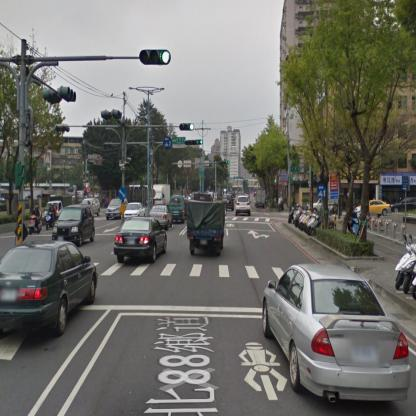

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Load the pre-trained yolov8n.pt model
# model = YOLO('yolo12n.pt')

# Define the path to the image for prediction
# image_path = os.path.join(to_train_path,'TrafficSignLocalizationandDetection/test/images/000539_jpg.rf.53a4e59b7b1c463d526fd835afa67135.jpg')
# image_path = os.path.join(to_train_path,'TrafficSignLocalizationandDetection/train/images/000100_jpg.rf.551371afbaccc11ec1b5faeb2bf3b52c.jpg')
# image_path = os.path.join(to_train_path,'TrafficSignLocalizationandDetection/test/images/000923_JPG.rf.25884ee05b10a072c952102bfeb64967.jpg')
image_path = os.path.join(to_train_path,'TrafficSignLocalizationandDetection/test/images/000943_JPG.rf.6e6e26139431d6b99a55847e3a05fd02.jpg')

# Make predictions on the image
results = model.predict(image_path)

# Load the image using OpenCV
img = cv2.imread(image_path)

# Iterate through the prediction results and draw bounding boxes
for r in results:
    # Check if there are any bounding boxes in the result
    if r.boxes is not None and len(r.boxes) > 0:
        for box in r.boxes:
            # Get the coordinates of the bounding box
            x1, y1, x2, y2 = [int(coord) for coord in box.xyxy[0]]

            # Draw the bounding box on the image
            color = (0, 255, 0)  # Green color for the bounding box
            thickness = 2
            cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)

            # Optionally, get the class and confidence and display them
            if box.cls is not None and box.conf is not None:
                class_id = int(box.cls[0])
                confidence = float(box.conf[0])
                class_name = model.names[class_id] # Get class name from model

                label = f"{class_name}: {confidence:.2f}"
                font = cv2.FONT_HERSHEY_SIMPLEX
                font_scale = 0.5
                font_thickness = 1
                text_size = cv2.getTextSize(label, font, font_scale, font_thickness)[0]
                text_x = x1
                text_y = y1 - 10 if y1 > 20 else y1 + text_size[1] + 10
                cv2.putText(img, label, (text_x, text_y), font, font_scale, color, font_thickness)


# Display the image with bounding boxes using cv2_imshow
cv2_imshow(img)